# Add Sharadar Metadata to LSEG Fundamentals CSV

This notebook enriches your LSEG fundamentals CSV with Sharadar ticker metadata (exchange, category, ADR status, sector, industry, market cap scale, etc.) so that all information is available in a single database table for Pipeline filtering.

## Metadata Columns Added

The following columns will be added with `sharadar_` prefix:

- `sharadar_exchange`: Exchange (NYSE, NASDAQ, NYSEMKT, etc.)
- `sharadar_category`: Stock category (Domestic Common Stock, ADR, ETF, etc.)
- `sharadar_is_adr`: Boolean ADR flag (1=True, 0=False)
- `sharadar_location`: Company location (USA, etc.)
- `sharadar_sector`: Sharadar sector
- `sharadar_industry`: Sharadar industry
- `sharadar_sicsector`: SIC sector
- `sharadar_sicindustry`: SIC industry
- `sharadar_scalemarketcap`: Market cap scale (1-6: Nano to Mega)

## Author
Kamran Sokhanvari / Hidden Point Capital

## 1. Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Sharadar Ticker Metadata

In [2]:
# Import functions from the script (single source of truth with deduplication fix)
import sys
sys.path.insert(0, '/app/examples/lseg_fundamentals')
from add_sharadar_metadata_to_fundamentals import (
    load_sharadar_tickers, 
    add_metadata_to_fundamentals,
    find_newest_csv,
    generate_output_filename
)

print("✓ Imported functions from add_sharadar_metadata_to_fundamentals.py")
print("  - load_sharadar_tickers() - loads and deduplicates Sharadar metadata")
print("  - add_metadata_to_fundamentals() - merges metadata with fundamentals")
print("  - find_newest_csv() - auto-detects newest CSV by date in filename")
print("  - generate_output_filename() - auto-generates output filename")
print("\n⚠️  DEDUPLICATION FIX: Handles multiple entries per ticker (keeps first occurrence)")

✓ Imported functions from add_sharadar_metadata_to_fundamentals.py
  - load_sharadar_tickers() - loads and deduplicates Sharadar metadata
  - add_metadata_to_fundamentals() - merges metadata with fundamentals
  - find_newest_csv() - auto-detects newest CSV by date in filename
  - generate_output_filename() - auto-generates output filename

⚠️  DEDUPLICATION FIX: Handles multiple entries per ticker (keeps first occurrence)


In [3]:
# Configuration
CSV_DIR = '/data/csv/'  # Directory containing LSEG fundamentals CSV files
SHARADAR_BUNDLE = 'sharadar'  # Sharadar bundle name

# Auto-detect newest CSV file by date in filename
print("Auto-detecting newest CSV file...")
INPUT_CSV = find_newest_csv(directory=CSV_DIR)

if INPUT_CSV is None:
    raise FileNotFoundError(f"No CSV files found in {CSV_DIR}")

# Auto-generate output filename
OUTPUT_CSV = generate_output_filename(INPUT_CSV)

print(f"Input CSV: {INPUT_CSV}")
print(f"Output CSV: {OUTPUT_CSV}")
print(f"Sharadar Bundle: {SHARADAR_BUNDLE}")

Auto-detecting newest CSV file...
Found 34 CSV files in /data/csv
  20091231_20260630.csv: 20091231 to 20260630
  20091231_20260609.csv: 20091231 to 20260609
  20091231_20260804.csv: 20091231 to 20260804
  20091231_20260623.csv: 20091231 to 20260623
  20091231_20260811.csv: 20091231 to 20260811
  20091231_20260721.csv: 20091231 to 20260721
  20091231_20260707.csv: 20091231 to 20260707
  20091231_20260714.csv: 20091231 to 20260714
  20091231_20260728.csv: 20091231 to 20260728
  20091231_20260602.csv: 20091231 to 20260602
  20091231_20260818.csv: 20091231 to 20260818

Newest file: 20091231_20260818.csv (20091231 to 20260818)
Input CSV: /data/csv/20091231_20260818.csv
Output CSV: /data/csv/20091231_20260818_with_metadata.csv
Sharadar Bundle: sharadar


In [4]:
# Load Sharadar metadata
sharadar_metadata = load_sharadar_tickers(SHARADAR_BUNDLE)

print(f"\nMetadata shape: {sharadar_metadata.shape}")
print(f"\nColumns: {list(sharadar_metadata.columns)}")
print(f"\nFirst 5 rows:")
sharadar_metadata.head()

Loading Sharadar tickers metadata...


Loaded 73980 tickers
After deduplication: 43959 unique tickers

Metadata shape: (43959, 10)

Columns: ['Symbol', 'exchange', 'category', 'location', 'sector', 'industry', 'sicsector', 'sicindustry', 'scalemarketcap', 'is_adr']

First 5 rows:


,Symbol,exchange,category,location,sector,industry,sicsector,sicindustry,scalemarketcap,is_adr
None,,,,,,,,,,
0,OAIW,NYSEARCA,ETF,Illinois; U.S.A,None,None,None,None,None,0
1,GAIQ,NYSEARCA,ETF,None,None,None,None,None,None,0
2,MPIM,NYSEARCA,ETF,Ohio; U.S.A,None,None,None,None,None,0
3,ZDIS,NYSEARCA,ETF,New York; U.S.A,None,None,None,None,None,0
4,ADAMK,NASDAQ,ETD,New York; U.S.A,None,None,Finance Insurance And Real Estate,Real Estate Investment Trusts,None,0


## 3. Metadata Summary Statistics

EXCHANGE DISTRIBUTION
exchange
NASDAQ      14986
NYSE         8243
NYSEARCA     4071
BATS         1953
NYSEMKT      1466
INDEX           5
OTC             4
Name: count, dtype: int64


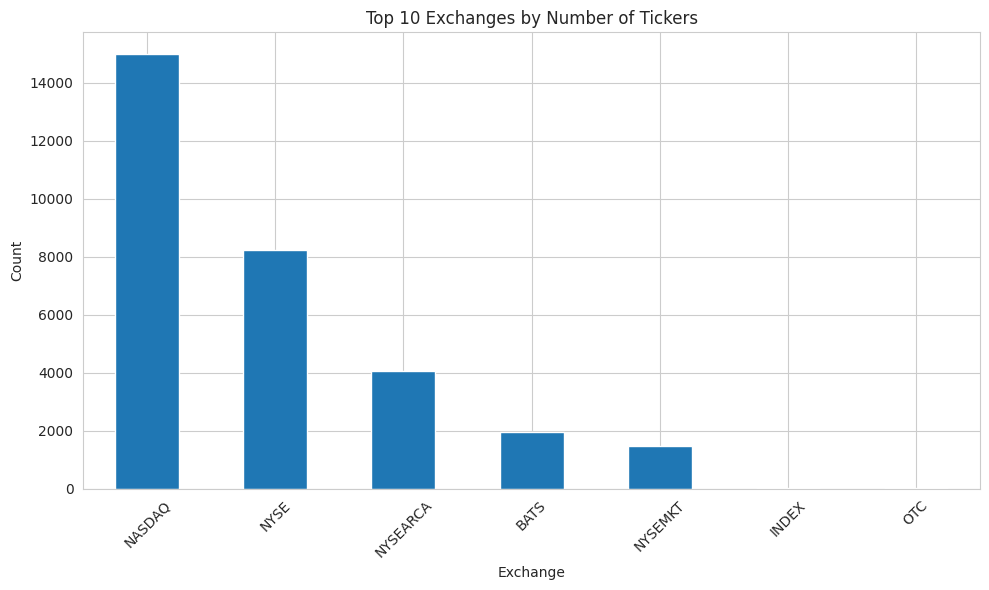

In [5]:
# Exchange distribution
print("=" * 80)
print("EXCHANGE DISTRIBUTION")
print("=" * 80)
print(sharadar_metadata['exchange'].value_counts())

# Plot
plt.figure(figsize=(10, 6))
sharadar_metadata['exchange'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Exchanges by Number of Tickers')
plt.xlabel('Exchange')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CATEGORY DISTRIBUTION
category
Domestic Common Stock                    13544
Institutional Investor                   13231
ETF                                       7657
Domestic Common Stock Primary Class       2182
ADR Common Stock                          1852
Domestic Common Stock Secondary Class     1325
Domestic Preferred Stock                  1137
CEF                                       1073
ETD                                        494
ETN                                        414
Canadian Common Stock                      383
ADR Common Stock Primary Class             265
ADR Common Stock Secondary Class           159
ADR Preferred Stock                         92
CEF Preferred                               82
UNIT                                        24
ETMF                                        18
Canadian Common Stock Primary Class         15
IDX                                          5
Canadian Preferred Stock                     3
Canadian Common Stock Seconda

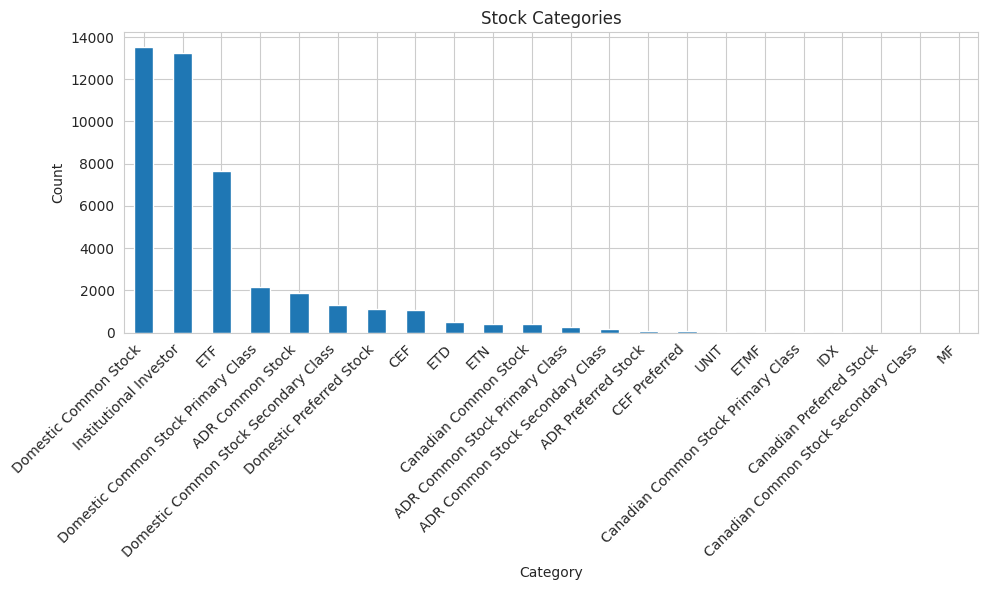

In [6]:
# Category distribution
print("=" * 80)
print("CATEGORY DISTRIBUTION")
print("=" * 80)
print(sharadar_metadata['category'].value_counts())

# Plot
plt.figure(figsize=(10, 6))
sharadar_metadata['category'].value_counts().plot(kind='bar')
plt.title('Stock Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ADR DISTRIBUTION
Non-ADRs: 41,591
ADRs: 2,368


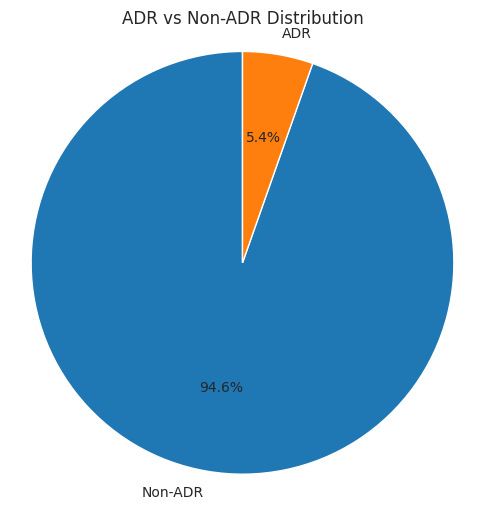

In [7]:
# ADR distribution
print("=" * 80)
print("ADR DISTRIBUTION")
print("=" * 80)
adr_counts = sharadar_metadata['is_adr'].value_counts()
print(f"Non-ADRs: {adr_counts.get(0, 0):,}")
print(f"ADRs: {adr_counts.get(1, 0):,}")

# Plot
plt.figure(figsize=(6, 6))
labels = ['Non-ADR', 'ADR']
sizes = [adr_counts.get(0, 0), adr_counts.get(1, 0)]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('ADR vs Non-ADR Distribution')
plt.axis('equal')
plt.show()

SECTOR DISTRIBUTION
sector
Industrials               3761
Technology                3608
Financial Services        3294
Healthcare                3095
Consumer Cyclical         1977
Communication Services    1174
Real Estate               1058
Basic Materials            991
Energy                     950
Consumer Defensive         786
Utilities                  407
Name: count, dtype: int64


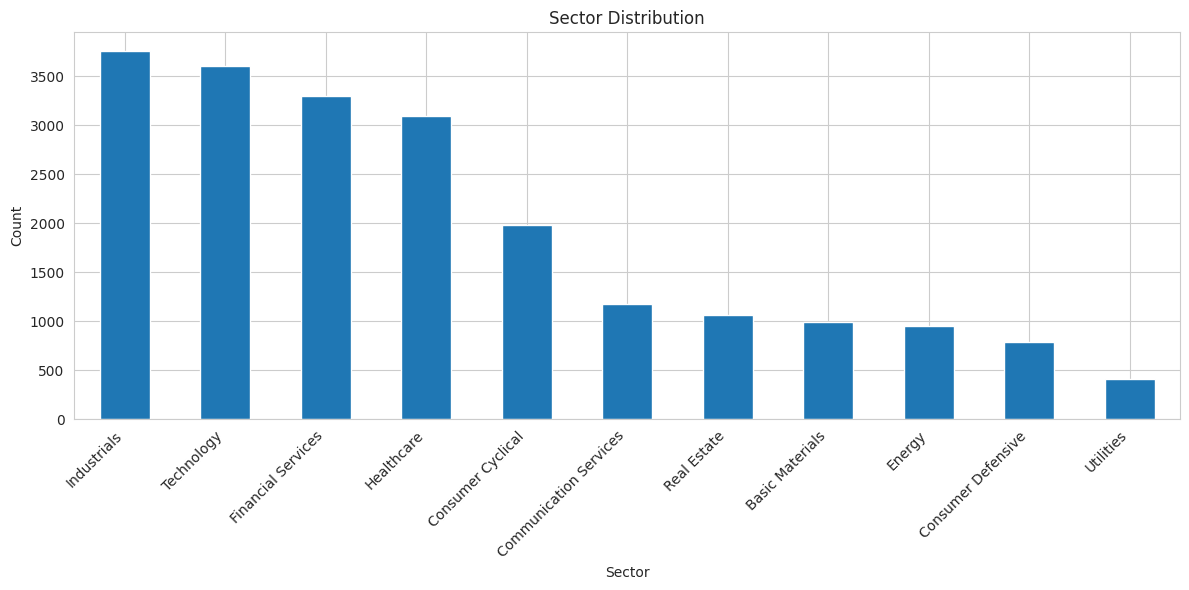

In [8]:
# Sector distribution
if 'sector' in sharadar_metadata.columns:
    print("=" * 80)
    print("SECTOR DISTRIBUTION")
    print("=" * 80)
    print(sharadar_metadata['sector'].value_counts())
    
    # Plot
    plt.figure(figsize=(12, 6))
    sharadar_metadata['sector'].value_counts().plot(kind='bar')
    plt.title('Sector Distribution')
    plt.xlabel('Sector')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

MARKET CAP SCALE DISTRIBUTION
scalemarketcap
1 - Nano     1546
2 - Micro    4572
3 - Small    6261
4 - Mid      3458
5 - Large    1816
6 - Mega      108
Name: count, dtype: int64


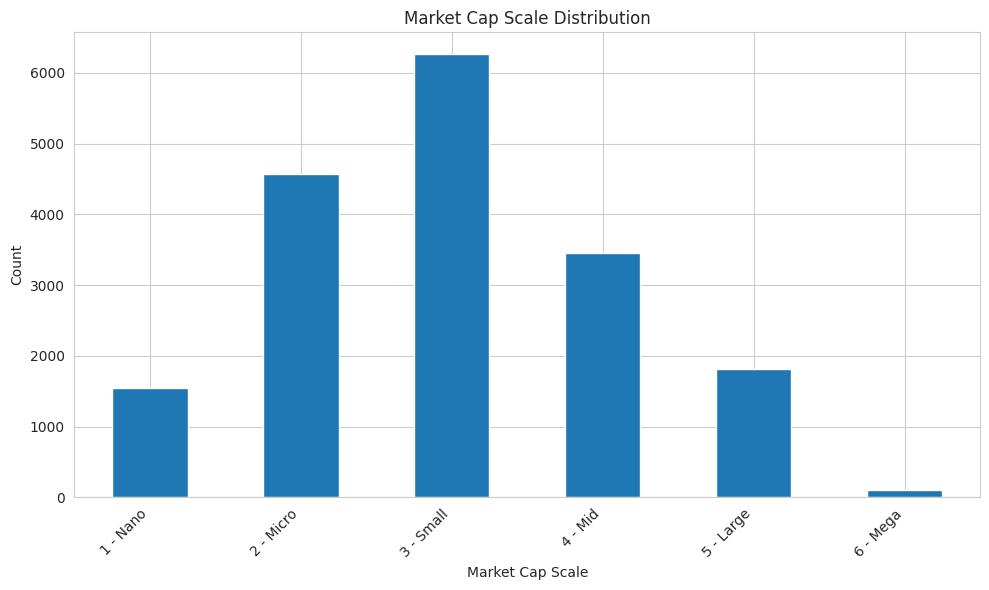

In [9]:
# Market cap scale distribution
if 'scalemarketcap' in sharadar_metadata.columns:
    print("=" * 80)
    print("MARKET CAP SCALE DISTRIBUTION")
    print("=" * 80)
    print(sharadar_metadata['scalemarketcap'].value_counts().sort_index())
    
    # Plot
    plt.figure(figsize=(10, 6))
    sharadar_metadata['scalemarketcap'].value_counts().sort_index().plot(kind='bar')
    plt.title('Market Cap Scale Distribution')
    plt.xlabel('Market Cap Scale')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Load LSEG Fundamentals CSV

In [10]:
# Load LSEG fundamentals
print(f"Loading LSEG fundamentals from: {INPUT_CSV}")
fundamentals = pd.read_csv(INPUT_CSV)

print(f"\nLoaded {len(fundamentals):,} rows, {len(fundamentals.columns)} columns")
print(f"\nColumns: {list(fundamentals.columns)}")

if 'Date' in fundamentals.columns:
    print(f"\nDate range: {fundamentals['Date'].min()} to {fundamentals['Date'].max()}")
    print(f"Unique dates: {fundamentals['Date'].nunique():,}")

if 'Symbol' in fundamentals.columns:
    print(f"Unique symbols: {fundamentals['Symbol'].nunique():,}")

print(f"\nFirst 5 rows:")
fundamentals.tail()

Loading LSEG fundamentals from: /data/csv/20091231_20260818.csv



Loaded 9,578,345 rows, 38 columns

Columns: ['Date', 'Symbol', 'Instrument', 'RefPriceClose', 'RefVolume', 'CompanyCommonName', 'EnterpriseValue_DailyTimeSeries_', 'CompanyMarketCap', 'GICSSectorName', 'FOCFExDividends_Discrete', 'InterestExpense_NetofCapitalizedInterest', 'Debt_Total', 'EarningsPerShare_Actual', 'EarningsPerShare_SmartEstimate_prev_Q', 'EarningsPerShare_ActualSurprise', 'EarningsPerShare_SmartEstimate_current_Q', 'LongTermGrowth_Mean', 'PriceTarget_Median', 'CombinedAlphaModelSectorRank', 'CombinedAlphaModelSectorRankChange', 'CombinedAlphaModelRegionRank', 'EarningsQualityRegionRank_Current', 'EnterpriseValueToEBIT_DailyTimeSeriesRatio_', 'EnterpriseValueToEBITDA_DailyTimeSeriesRatio_', 'EnterpriseValueToSales_DailyTimeSeriesRatio_', 'Dividend_Per_Share_SmartEstimate', 'CashCashEquivalents_Total', 'ForwardPEG_DailyTimeSeriesRatio_', 'PriceEarningsToGrowthRatio_SmartEstimate_', 'Recommendation_Median_1_5_', 'ReturnOnEquity_SmartEstimat', 'ReturnOnAssets_SmartEstimate


Date range: 2008-10-16 00:00:00.000000000 to 2026-08-18 00:00:00.000000000


Unique dates: 4,198
Unique symbols: 4,759

First 5 rows:


,Date,Symbol,Instrument,RefPriceClose,RefVolume,CompanyCommonName,EnterpriseValue_DailyTimeSeries_,CompanyMarketCap,GICSSectorName,FOCFExDividends_Discrete,InterestExpense_NetofCapitalizedInterest,Debt_Total,EarningsPerShare_Actual,EarningsPerShare_SmartEstimate_prev_Q,EarningsPerShare_ActualSurprise,EarningsPerShare_SmartEstimate_current_Q,LongTermGrowth_Mean,PriceTarget_Median,CombinedAlphaModelSectorRank,CombinedAlphaModelSectorRankChange,CombinedAlphaModelRegionRank,EarningsQualityRegionRank_Current,EnterpriseValueToEBIT_DailyTimeSeriesRatio_,EnterpriseValueToEBITDA_DailyTimeSeriesRatio_,EnterpriseValueToSales_DailyTimeSeriesRatio_,Dividend_Per_Share_SmartEstimate,CashCashEquivalents_Total,ForwardPEG_DailyTimeSeriesRatio_,PriceEarningsToGrowthRatio_SmartEstimate_,Recommendation_Median_1_5_,ReturnOnEquity_SmartEstimat,ReturnOnAssets_SmartEstimate,ForwardPriceToCashFlowPerShare_DailyTimeSeriesRatio_,ForwardPriceToSalesPerShare_DailyTimeSeriesRatio_,ForwardEnterpriseValueToOperatingCashFlow_DailyTimeSeriesRatio_,GrossProfitMargin_ActualSurprise,Estpricegrowth_percent,TradeDate
9578340,2026-08-18 00:00:00.000000000,ZTS,ZTS.N,73.96,1388483.0,Zoetis Inc,3.793702e+10,3.056202e+10,Health Care,538000000.0,61000000.0,9.049000e+09,1.87,1.85001,-5.249,1.49630,6.225,95.0,68.0,-11.0,57.0,71.0,10.427987,9.199083,3.986237,0.53189,1.473000e+09,1.867439,24.537939,3.0,66.5748,10.7,9.978566,3.268701,12.386520,-0.309,0.284478,2026-08-18
9578341,2026-08-18 00:00:00.000000000,ZURA,ZURA.OQ,5.77,285135.0,Zura Bio Ltd,3.478001e+08,5.529341e+08,Health Care,-20925000.0,NaN,9.900000e+05,-0.21,-0.19809,-26.437,-0.20828,NaN,19.0,26.0,13.0,11.0,1.0,NaN,NaN,NaN,NaN,2.051340e+08,NaN,NaN,1.0,NaN,NaN,NaN,117.344798,NaN,NaN,2.292894,2026-08-18
9578342,2026-08-18 00:00:00.000000000,ZVRA,ZVRA.OQ,11.57,266622.0,Zevra Therapeutics Inc,4.655003e+08,6.870703e+08,Health Care,16815000.0,1711000.0,6.192800e+07,0.14,0.11823,122.827,0.16169,NaN,24.5,90.0,27.0,92.0,81.0,5.650579,5.549930,3.421011,NaN,1.453210e+08,NaN,341.651999,2.0,7.0000,NaN,10.731197,4.081034,7.270545,2.181,1.117545,2026-08-18
9578343,2026-08-18 00:00:00.000000000,ZWS,ZWS.N,49.21,216876.0,Zurn Elkay Water Solutions Corp,8.296272e+09,8.162172e+09,Industrials,159400000.0,6100000.0,4.965000e+08,0.50,0.47623,5.419,0.50198,14.485,58.0,61.0,10.0,54.0,91.0,24.537924,19.552845,4.643609,0.11000,3.650000e+08,1.742405,6.264197,2.5,15.6000,NaN,19.355331,4.255575,19.673328,-4.178,0.178622,2026-08-18
9578344,2026-08-18 00:00:00.000000000,ZYME,ZYME.OQ,26.07,190105.0,Zymeworks Inc.,1.831839e+09,1.849907e+09,Health Care,-31948000.0,6508000.0,5.600000e+04,-0.62,-0.58253,-207.292,2.24301,NaN,38.5,74.0,23.0,69.0,1.0,2.772842,2.648218,49.339818,NaN,1.794130e+08,NaN,0.093909,2.0,427.8100,NaN,140.141768,7.194927,138.773007,NaN,0.476793,2026-08-18


## 5. Merge Metadata with Fundamentals

In [11]:
# Merge
enriched = add_metadata_to_fundamentals(fundamentals, sharadar_metadata)

print(f"\n{'='*80}")
print("ENRICHED DATA SUMMARY")
print(f"{'='*80}")
print(f"Original columns: {len(fundamentals.columns)}")
print(f"Enriched columns: {len(enriched.columns)}")
print(f"Metadata columns added: {len([c for c in enriched.columns if c.startswith('sharadar_')])}")


Merging metadata...
Fundamentals shape: (9578345, 38)
Metadata shape: (43959, 10)


Merged shape: (9578345, 47)



Matching statistics:
  Total rows: 9,578,345
  Unique symbols: 4,759
  Rows with metadata: 9,081,330 (94.8%)



ENRICHED DATA SUMMARY
Original columns: 38
Enriched columns: 47
Metadata columns added: 9


## 6. Preview Enriched Data

In [12]:
# Show preview with metadata columns
metadata_cols = [col for col in enriched.columns if col.startswith('sharadar_')]
preview_cols = ['Date', 'Symbol'] + metadata_cols
preview_cols = [col for col in preview_cols if col in enriched.columns]

print("=" * 80)
print("PREVIEW (first 10 rows with metadata):")
print("=" * 80)
print(enriched[preview_cols].tail(10).to_string())

PREVIEW (first 10 rows with metadata):


                                  Date Symbol sharadar_exchange                    sharadar_category  sharadar_location sharadar_sector                         sharadar_industry                 sharadar_sicsector                                sharadar_sicindustry sharadar_scalemarketcap  sharadar_is_adr
9578335  2026-08-18 00:00:00.000000000    ZKP            NASDAQ  Domestic Common Stock Primary Class     Florida; U.S.A     Industrials                           Shell Companies  Finance Insurance And Real Estate                                        Blank Checks               3 - Small                0
9578336  2026-08-18 00:00:00.000000000     ZM            NASDAQ                Domestic Common Stock  California; U.S.A      Technology                    Software - Application                           Services  Services-Computer Programming Data Processing Etc.               5 - Large                0
9578337  2026-08-18 00:00:00.000000000   ZNOG            NASDAQ                Dom

In [13]:
# Metadata column summary
print("\n" + "=" * 80)
print("METADATA COLUMN SUMMARY")
print("=" * 80)

for col in sorted(metadata_cols):
    unique_count = enriched[col].nunique()
    null_count = enriched[col].isna().sum()
    empty_count = (enriched[col] == '').sum()
    print(f"{col:40s}: {unique_count:6,} unique, {null_count:8,} nulls, {empty_count:8,} empty")


METADATA COLUMN SUMMARY


sharadar_category                       :     13 unique,        0 nulls,  497,015 empty


sharadar_exchange                       :      7 unique,        0 nulls,  497,015 empty


sharadar_industry                       :    145 unique,        0 nulls, 1,194,216 empty
sharadar_is_adr                         :      2 unique,        0 nulls,        0 empty


sharadar_location                       :     74 unique,        0 nulls,  517,464 empty


sharadar_scalemarketcap                 :      7 unique,        0 nulls, 1,217,029 empty


sharadar_sector                         :     12 unique,        0 nulls, 1,194,216 empty


sharadar_sicindustry                    :    368 unique,        0 nulls, 1,180,181 empty


sharadar_sicsector                      :     10 unique,        0 nulls, 1,180,181 empty


In [14]:
# Sample specific symbols to verify metadata
print("\n" + "=" * 80)
print("SAMPLE SYMBOLS WITH METADATA")
print("=" * 80)

sample_symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
available_samples = [s for s in sample_symbols if s in enriched['Symbol'].values]

if available_samples:
    sample_data = enriched[enriched['Symbol'].isin(available_samples)][preview_cols].drop_duplicates('Symbol')
    print(sample_data.to_string())
else:
    print("None of the sample symbols found in data")


SAMPLE SYMBOLS WITH METADATA


                                 Date Symbol sharadar_exchange                    sharadar_category  sharadar_location         sharadar_sector               sharadar_industry sharadar_sicsector                                sharadar_sicindustry sharadar_scalemarketcap  sharadar_is_adr
26      2009-12-31 00:00:00.000000000   AAPL            NASDAQ                Domestic Common Stock  California; U.S.A              Technology            Consumer Electronics      Manufacturing                                Electronic Computers                6 - Mega                0
101     2009-12-31 00:00:00.000000000   AMZN            NASDAQ                Domestic Common Stock  Washington; U.S.A       Consumer Cyclical                 Internet Retail       Retail Trade                  Retail-Catalog & Mail-Order Houses                6 - Mega                0
636     2009-12-31 00:00:00.000000000  GOOGL            NASDAQ  Domestic Common Stock Primary Class  California; U.S.A  Communication Servi

## 7. Metadata Distribution in Enriched Data

In [15]:
# Get unique symbol-level data for analysis
unique_symbols = enriched[['Symbol'] + metadata_cols].drop_duplicates('Symbol')

print(f"Analyzing {len(unique_symbols):,} unique symbols")

Analyzing 4,759 unique symbols


EXCHANGE DISTRIBUTION (in enriched data)
sharadar_exchange
NASDAQ      2176
NYSE        1909
             541
NYSEMKT       75
NYSEARCA      46
BATS          10
OTC            2
Name: count, dtype: int64


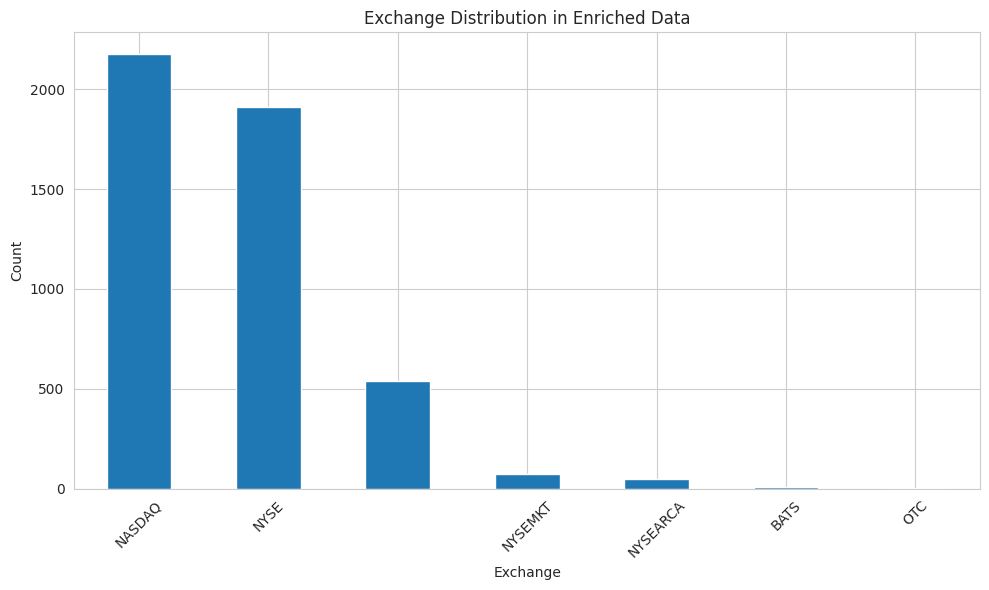

In [16]:
# Exchange distribution in enriched data
if 'sharadar_exchange' in unique_symbols.columns:
    print("=" * 80)
    print("EXCHANGE DISTRIBUTION (in enriched data)")
    print("=" * 80)
    exchange_dist = unique_symbols['sharadar_exchange'].value_counts()
    print(exchange_dist)
    
    # Plot
    plt.figure(figsize=(10, 6))
    exchange_dist.head(10).plot(kind='bar')
    plt.title('Exchange Distribution in Enriched Data')
    plt.xlabel('Exchange')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

CATEGORY DISTRIBUTION (in enriched data)
sharadar_category
Domestic Common Stock                    2863
Domestic Common Stock Primary Class       939
                                          541
CEF                                       263
ETF                                        66
Domestic Common Stock Secondary Class      37
ADR Common Stock                           21
ADR Common Stock Primary Class             14
Canadian Common Stock                       5
Domestic Preferred Stock                    4
UNIT                                        2
ETD                                         2
ADR Common Stock Secondary Class            2
Name: count, dtype: int64


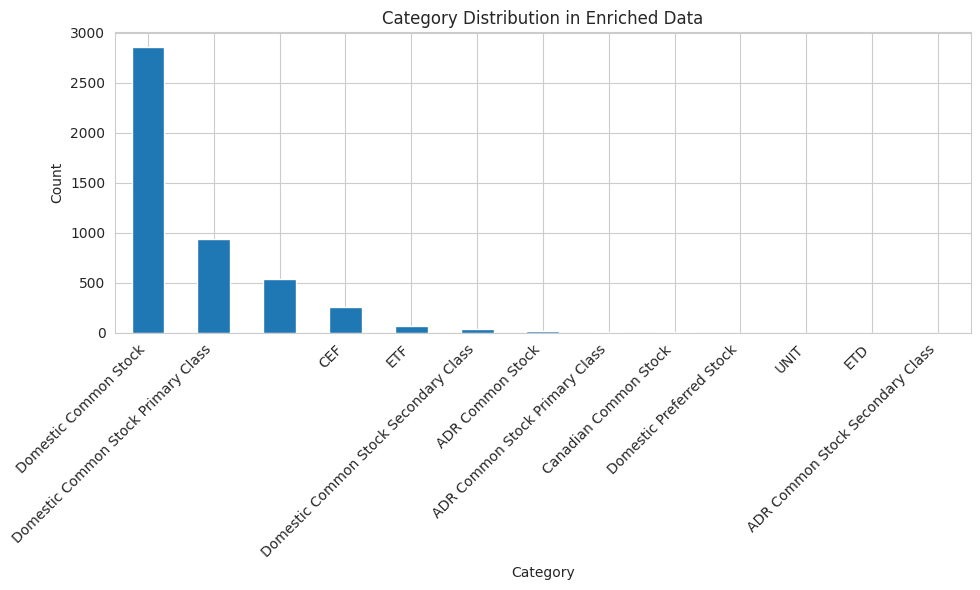

In [17]:
# Category distribution in enriched data
if 'sharadar_category' in unique_symbols.columns:
    print("=" * 80)
    print("CATEGORY DISTRIBUTION (in enriched data)")
    print("=" * 80)
    category_dist = unique_symbols['sharadar_category'].value_counts()
    print(category_dist)
    
    # Plot
    plt.figure(figsize=(10, 6))
    category_dist.plot(kind='bar')
    plt.title('Category Distribution in Enriched Data')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

SECTOR DISTRIBUTION (in enriched data)
sharadar_sector
                          875
Industrials               736
Healthcare                730
Financial Services        570
Technology                549
Consumer Cyclical         360
Real Estate               222
Energy                    178
Basic Materials           177
Consumer Defensive        143
Communication Services    133
Utilities                  86
Name: count, dtype: int64


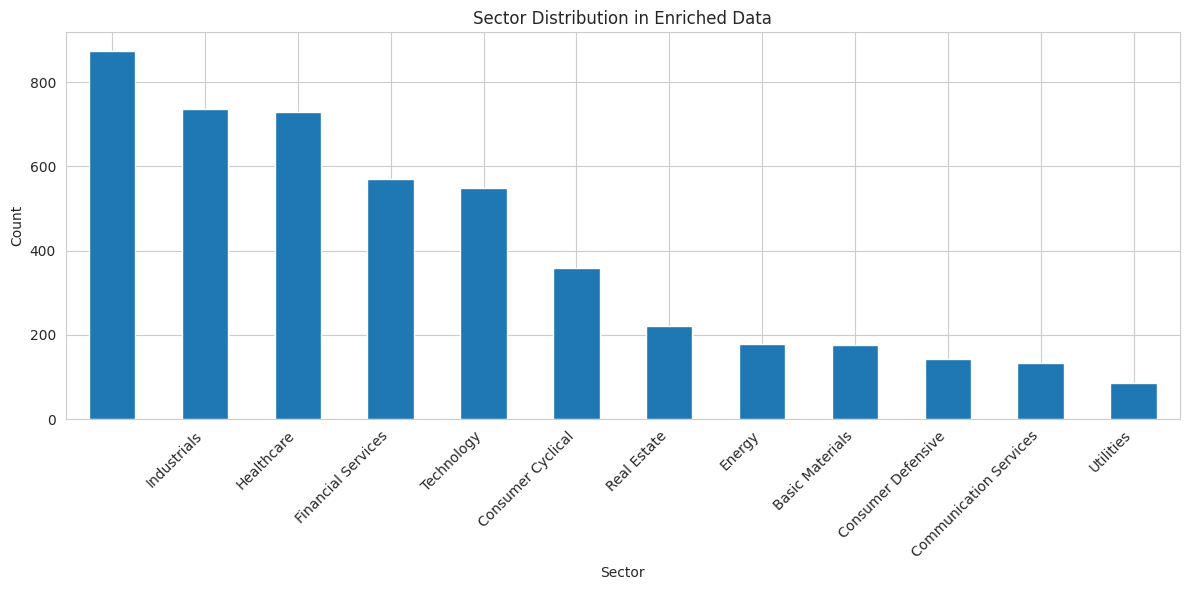

In [18]:
# Sector distribution in enriched data
if 'sharadar_sector' in unique_symbols.columns:
    print("=" * 80)
    print("SECTOR DISTRIBUTION (in enriched data)")
    print("=" * 80)
    sector_dist = unique_symbols['sharadar_sector'].value_counts()
    print(sector_dist)
    
    # Plot
    plt.figure(figsize=(12, 6))
    sector_dist.plot(kind='bar')
    plt.title('Sector Distribution in Enriched Data')
    plt.xlabel('Sector')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 8. Save Enriched CSV

In [19]:
# Save enriched data
print(f"Saving enriched data to: {OUTPUT_CSV}")
enriched.to_csv(OUTPUT_CSV, index=False)

print(f"\n✓ Saved {len(enriched):,} rows to {OUTPUT_CSV}")

Saving enriched data to: /data/csv/20091231_20260818_with_metadata.csv



✓ Saved 9,578,345 rows to /data/csv/20091231_20260818_with_metadata.csv


## 9. Summary Report

In [20]:
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Original columns: {len(fundamentals.columns)}")
print(f"Enriched columns: {len(enriched.columns)}")
print(f"Metadata columns added: {len(metadata_cols)}")

print("\nNew metadata columns:")
for col in sorted(metadata_cols):
    print(f"  - {col}")

print("\n" + "=" * 80)
print("NEXT STEPS")
print("=" * 80)
print(f"1. Load the enriched CSV into fundamentals.sqlite:")
print(f"   python examples/lseg_fundamentals/load_csv_fundamentals.py")
print(f"")
print(f"2. Use the metadata columns in your Pipeline strategies:")
print(f"   - Filter by exchange: sharadar_exchange")
print(f"   - Filter by category: sharadar_category")
print(f"   - Exclude ADRs: sharadar_is_adr == 0")
print(f"   - Filter by sector: sharadar_sector")
print(f"   - Filter by market cap scale: sharadar_scalemarketcap")
print(f"")
print(f"3. Example Pipeline filter:")
print(f"   exchange_filter = (CustomFundamentals.sharadar_exchange.latest == 'NYSE')")
print(f"   category_filter = (CustomFundamentals.sharadar_category.latest == 'Domestic Common Stock')")
print(f"   no_adr_filter = (CustomFundamentals.sharadar_is_adr.latest == 0)")
print(f"   universe = exchange_filter & category_filter & no_adr_filter")
print("\n✓ Done!")


FINAL SUMMARY
Original columns: 38
Enriched columns: 47
Metadata columns added: 9

New metadata columns:
  - sharadar_category
  - sharadar_exchange
  - sharadar_industry
  - sharadar_is_adr
  - sharadar_location
  - sharadar_scalemarketcap
  - sharadar_sector
  - sharadar_sicindustry
  - sharadar_sicsector

NEXT STEPS
1. Load the enriched CSV into fundamentals.sqlite:
   python examples/lseg_fundamentals/load_csv_fundamentals.py

2. Use the metadata columns in your Pipeline strategies:
   - Filter by exchange: sharadar_exchange
   - Filter by category: sharadar_category
   - Exclude ADRs: sharadar_is_adr == 0
   - Filter by sector: sharadar_sector
   - Filter by market cap scale: sharadar_scalemarketcap

3. Example Pipeline filter:
   exchange_filter = (CustomFundamentals.sharadar_exchange.latest == 'NYSE')
   category_filter = (CustomFundamentals.sharadar_category.latest == 'Domestic Common Stock')
   no_adr_filter = (CustomFundamentals.sharadar_is_adr.latest == 0)
   universe = exc

## 10. Sample Data for AAPL

View the last 10 rows of enriched data for AAPL to see all columns with metadata.

In [21]:
# Get last 10 rows for AAPL
print("=" * 80)
print("LAST 10 ROWS FOR AAPL (with all columns)")
print("=" * 80)

if 'AAPL' in enriched['Symbol'].values:
    aapl_data = enriched[enriched['Symbol'] == 'AAPL'].tail(10)
    
    print(f"\nShowing last 10 rows of {len(enriched[enriched['Symbol'] == 'AAPL'])} total rows for AAPL")
    print(f"Date range: {aapl_data['Date'].min()} to {aapl_data['Date'].max()}")
    print(f"\nColumns: {len(aapl_data.columns)}")
    print("\n" + "=" * 80)
    
    # Display with pandas settings for full visibility
    with pd.option_context('display.max_columns', None,
                          'display.max_rows', None,
                          'display.width', None,
                          'display.max_colwidth', 50):
        print(aapl_data)
    
    print("\n" + "=" * 80)
    print("AAPL METADATA SUMMARY")
    print("=" * 80)
    
    # Show just the metadata columns for clarity
    metadata_cols_display = [col for col in aapl_data.columns if col.startswith('sharadar_')]
    if metadata_cols_display:
        aapl_metadata = aapl_data[['Date', 'Symbol'] + metadata_cols_display].tail(1)
        print("\nSharadar Metadata for AAPL:")
        for col in metadata_cols_display:
            value = aapl_metadata[col].iloc[0]
            print(f"  {col:40s}: {value}")
else:
    print("AAPL not found in enriched data")

LAST 10 ROWS FOR AAPL (with all columns)



Showing last 10 rows of 4182 total rows for AAPL
Date range: 2026-08-05 00:00:00.000000000 to 2026-08-18 00:00:00.000000000

Columns: 47

                                  Date Symbol Instrument  RefPriceClose  \
9548679  2026-08-05 00:00:00.000000000   AAPL    AAPL.OQ         311.00   
9551648  2026-08-06 00:00:00.000000000   AAPL    AAPL.OQ         312.41   
9554626  2026-08-07 00:00:00.000000000   AAPL    AAPL.OQ         313.33   
9557599  2026-08-10 00:00:00.000000000   AAPL    AAPL.OQ         308.26   
9560581  2026-08-11 00:00:00.000000000   AAPL    AAPL.OQ         304.91   
9563570  2026-08-12 00:00:00.000000000   AAPL    AAPL.OQ         302.25   
9566523  2026-08-13 00:00:00.000000000   AAPL    AAPL.OQ         305.26   
9569476  2026-08-14 00:00:00.000000000   AAPL    AAPL.OQ         305.93   
9572435  2026-08-17 00:00:00.000000000   AAPL    AAPL.OQ         305.59   
9575394  2026-08-18 00:00:00.000000000   AAPL    AAPL.OQ         310.03   

          RefVolume CompanyCommonNa